<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Data_Preparation_RNN_and_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MSc Project - Data Preparation for LSTM

This notebook contains code for and MSc Project about predicting time-to-failure of water mains in Scotland. In particular, the code contains data preparation for the LSTM model - cleaning and manipulation.

## Import Data

Data has already been cleaned and joined and the resultant data is imported into this notebook.

In [1]:
# mount Google Drive

from google.colab import drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [42]:
# import data

import pandas as pd

data_cleaned_joined = pd.read_csv("/content/drive/MyDrive/MSc project/data_cleaned_joined.csv", encoding = "latin1")

In [43]:
# transform commissioned date to date type

data_cleaned_joined['Date_commissioned'] = pd.to_datetime(data_cleaned_joined['Date_commissioned'])

data_cleaned_joined['Raised.Date'] = pd.to_datetime(data_cleaned_joined['Raised.Date'])

## Feature Engineering

"Previous bursts" column is added.

In [44]:
# add previous bursts

total_bursts = data_cleaned_joined['Asset.ID'].value_counts().reset_index()

data_cleaned_joined = data_cleaned_joined.sort_values(["Asset.ID", "Raised.Date"])

for asset in data_cleaned_joined['Asset.ID']:

  previous_bursts = total_bursts['count'][total_bursts['Asset.ID'] == asset]

  data_cleaned_joined.loc[data_cleaned_joined['Asset.ID'] == asset, "Previous bursts"] = list(range(previous_bursts.iloc[0]))


data_cleaned_joined_engineered = data_cleaned_joined

Attribute "Time-to-failure" is added.

In [45]:
# add time-to-failure

start_date = data_cleaned_joined['Raised.Date'].min()
data_cleaned_joined_engineered_draft = []


for asset, bursts in data_cleaned_joined_engineered.groupby("Asset.ID"):

  for _,row in bursts.iterrows():

    if(row["Previous bursts"] == 0 and row["Date_commissioned"] > start_date):

      row["Time-to-failure"] = row["Raised.Date"] - row["Date_commissioned"]


    elif(row['Previous bursts'] == 0):

      row["Time-to-failure"] = row["Raised.Date"] - start_date


    else:

      row['Time-to-failure'] = row['Raised.Date'] - prev_row["Raised.Date"]

    data_cleaned_joined_engineered_draft.append(row)
    prev_row = row

data_cleaned_joined_engineered = pd.DataFrame(data_cleaned_joined_engineered_draft)

Column "Age" is added.

In [46]:
# add age

data_cleaned_joined_engineered_draft = []


for asset, bursts in data_cleaned_joined_engineered.groupby("Asset.ID"):

  for _,row in bursts.iterrows():

    if(row['Previous bursts'] == 0 and row["Date_commissioned"] > start_date):

      row["Age"] = start_date - start_date # this is used to obtain 0 days (0 in data type date)


    elif(row["Previous bursts"] == 0):

      row["Age"] = start_date - row["Date_commissioned"]


    else:

      row['Age'] = prev_row["Age"] + prev_row["Time-to-failure"]

    data_cleaned_joined_engineered_draft.append(row)
    prev_row = row

data_cleaned_joined_engineered = pd.DataFrame(data_cleaned_joined_engineered_draft)

In [47]:
# transform days to years

data_cleaned_joined_engineered['Time-to-failure'] = data_cleaned_joined_engineered["Time-to-failure"].dt.days/365

data_cleaned_joined_engineered["Age"] = data_cleaned_joined_engineered["Age"].dt.days/365

# Data Cleaning

In [48]:
# remove missing values

data_cleaned_joined_engineered = data_cleaned_joined_engineered[pd.notnull(data_cleaned_joined_engineered["Soil_pH"])]
data_cleaned_joined_engineered = data_cleaned_joined_engineered[pd.notnull(data_cleaned_joined_engineered["Hydrogen Ion"])]
data_cleaned_joined_engineered = data_cleaned_joined_engineered[pd.notnull(data_cleaned_joined_engineered["Free chlorine"])]


In [49]:
# train, test and valid split

train = data_cleaned_joined_engineered[data_cleaned_joined_engineered['Raised.Date'] <= "2019-12-31"]

valid = data_cleaned_joined_engineered[(data_cleaned_joined_engineered['Raised.Date'] >= "2020-01-01") & (data_cleaned_joined_engineered['Raised.Date'] <= "2021-12-31")]

test = data_cleaned_joined_engineered[data_cleaned_joined_engineered['Raised.Date'] >= "2022-01-01"]

# comment: cleaning has to be done after the split

(array([8.46e+03, 4.27e+02, 8.90e+01, 3.00e+01, 1.00e+01, 6.00e+00,
        1.00e+00, 1.00e+00, 1.00e+00, 1.00e+00]),
 array([ 1. ,  6.2, 11.4, 16.6, 21.8, 27. , 32.2, 37.4, 42.6, 47.8, 53. ]),
 <BarContainer object of 10 artists>)

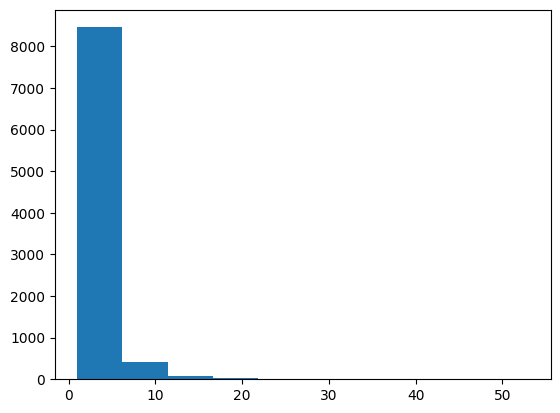

In [ ]:
# examine failure frequency per asset

import matplotlib.pyplot as plt

plt.hist(data_cleaned_joined_engineered['Asset.ID'].value_counts())

# comment: most of the assets have 5 or less failures

In [52]:
# get assets that had 5 or more bursts only

index_train = train['Asset.ID'].value_counts()[train['Asset.ID'].value_counts() >= 5].index
index_valid = valid['Asset.ID'].value_counts()[valid['Asset.ID'].value_counts() >= 5].index
index_test = test['Asset.ID'].value_counts()[test['Asset.ID'].value_counts() >= 5].index


In [53]:
# filter data for assets with 5 or more bursts only

train = train[train['Asset.ID'].isin(index_train)]
valid = valid[valid['Asset.ID'].isin(index_valid)]
test = test[test['Asset.ID'].isin(index_test)]



In [54]:
# get index for latest five bursts for each asset

index_train = train.groupby("Asset.ID")["Age"].nlargest(5).reset_index(level = 0, drop = True).index
index_valid = valid.groupby("Asset.ID")["Age"].nlargest(5).reset_index(level = 0, drop = True).index
index_test = test.groupby("Asset.ID")["Age"].nlargest(5).reset_index(level = 0, drop = True).index




In [55]:
# filter data to containt only latest five bursts

train = train.loc[index_train]
valid = valid.loc[index_valid]
test = test.loc[index_test]




In [57]:
X_train_sequential = train[["Asset.ID", "Material", "Diameter", "Length", "Lining", "Surface", "Soil", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Previous bursts", "Age"]]
y_train_sequential = train['Time-to-failure']

In [58]:
X_test_sequential = test[["Asset.ID", "Material", "Diameter", "Length", "Lining", "Surface", "Soil", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Previous bursts", "Age"]]
y_test_sequential = test['Time-to-failure']

In [59]:
X_valid_sequential = valid[["Asset.ID", "Material", "Diameter", "Length", "Lining", "Surface", "Soil", "Soil_pH", "Frost_days", "Hydrogen Ion", "Free chlorine", "Previous bursts", "Age"]]
y_valid_sequential = valid['Time-to-failure']

In [60]:
X_train_sequential.to_csv("/content/drive/MyDrive/MSc project/X_train_sequential.csv", encoding ='latin1', index=False)
y_train_sequential.to_csv("/content/drive/MyDrive/MSc project/y_train_sequential.csv", encoding ='latin1', index=False)

X_test_sequential.to_csv("/content/drive/MyDrive/MSc project/X_test_sequential.csv", encoding ='latin1', index=False)
y_test_sequential.to_csv("/content/drive/MyDrive/MSc project/y_test_sequential.csv", encoding ='latin1', index=False)


X_valid_sequential.to_csv("/content/drive/MyDrive/MSc project/X_valid_sequential.csv", encoding ='latin1', index=False)
y_valid_sequential.to_csv("/content/drive/MyDrive/MSc project/y_valid_sequential.csv", encoding ='latin1', index=False)
